# Vector Database & ANN Retrieval (Rubric §3.1–3.3)

Implements, over the KNN-imputed catalog (`imputed_dataset/imputed_dataset.csv`, 8,485 devices):

1. **Step 1 — Paragraph-aware + token-constrained chunking** via a Spark UDF (rubric §3.2 mandates Spark UDFs / mapPartitions), producing the chunk schema (`chunk_type, chunk_text, laptop_id, brand, model, price_value, price_currency, chunk_id, char_len`) built from the imputed dataset alone.
2. **Step 2 — Embedding** with `BAAI/bge-base-en-v1.5` (768-d, L2-normalized) via a `pandas_udf` (rubric §3.2), persisted with metadata to Parquet.
3. **Step 3 — Qdrant** vector database (local persistent, COSINE, 768-d) with payload filtering and a recall spot-check.
4. **Step 4 — Five-FAISS-index ANN benchmark** (Flat / IVF / PQ / IVF+PQ / HNSW) with recall@k, precision@k (k = 1, 3, 5, 10), accuracy, training time, build time, average query latency (p50/p95/mean), and index size.
5. **Step 5 — Bar charts + written justification** for the final index choice.

> Windows note: the review-KNN/embedding stages of this project run on the driver when `USE_PANDAS_UDF = False` (torch inside Spark workers is unstable on Windows). On Colab (Linux) set `USE_PANDAS_UDF = True`.

In [ ]:
# --- Colab environment setup: Java 17 (for PySpark) + Python deps ---
import os, sys, subprocess

IS_COLAB = "/content" in os.getcwd() or "google.colab" in sys.modules

def run(cmd, **kw):
    print("$", cmd)
    subprocess.check_call(cmd, shell=True, stdout=subprocess.DEVNULL, **kw)

if IS_COLAB:
    # 1) Java 17 (headless) — required by PySpark
    if not os.path.isdir("/usr/lib/jvm/java-17-openjdk-amd64"):
        run("apt-get -y install openjdk-17-jdk-headless >/dev/null 2>&1")
    os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
    os.environ["PATH"] = os.path.join(os.environ["JAVA_HOME"], "bin") + ":" + os.environ["PATH"]
    print("JAVA_HOME =", os.environ["JAVA_HOME"])
else:
    print("Running outside Colab — set JAVA_HOME yourself if PySpark fails.")

# 2) Python packages (idempotent)
for mod, name in [("pyspark", "pyspark"), ("sentence_transformers", "sentence-transformers"),
                  ("faiss", "faiss-cpu"), ("qdrant_client", "qdrant-client")]:
    try:
        __import__(mod)
        print("OK  ", name)
    except ImportError:
        print("INST", name)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", name])
        __import__(mod)

$ apt-get -y install openjdk-17-jdk-headless >/dev/null 2>&1
JAVA_HOME = /usr/lib/jvm/java-17-openjdk-amd64
OK   pyspark
OK   sentence-transformers
INST faiss-cpu
INST qdrant-client


In [ ]:
# --- Mount Google Drive and locate the dataset ---
# Uses the Drive folder ID directly (not a guessed path): Colab exposes any shared
# Drive item at /content/drive/.shortcut-targets-by-id/<ID> right after mounting,
# regardless of what it's named or where it lives in your Drive.
#
# IMPORTANT: all Spark writes below go to LOCAL_OUT_DIR (Colab's local disk), not
# directly to Drive. Writing large distributed parquet output straight to Drive's
# FUSE mount is unreliable in practice -- an in-session read-back can pass (served
# from a local cache) while the copy that actually lands on Drive's cloud storage
# ends up incomplete/corrupted. DRIVE_OUT_DIR is only a copy DESTINATION: after
# each expensive artifact is written and verified locally, a separate cell copies
# the already-complete file to Drive as a plain, atomic file copy.
if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_FOLDER_ID = "1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4"
    DRIVE_SRC = f"/content/drive/.shortcut-targets-by-id/{DRIVE_FOLDER_ID}/CSE488"

    import subprocess as _sp
    print(_sp.run(["find", DRIVE_SRC, "-maxdepth", "2"], capture_output=True, text=True).stdout)

    # --- ADJUST if the listing above doesn't show these paths ---
    DATASET_CSV = f"{DRIVE_SRC}/Dataset/imputed_dataset.csv"
    DRIVE_OUT_DIR = f"{DRIVE_SRC}/vector_db_artifacts"      # copy DESTINATION only
    LOCAL_OUT_DIR = "/content/vector_db_artifacts"          # Spark writes here

    assert os.path.isfile(DATASET_CSV), f"DATASET_CSV not found: {DATASET_CSV} -- fix the path above"
    print("DATASET_CSV OK:", DATASET_CSV)
    print("Spark will write to (local, reliable):", LOCAL_OUT_DIR)
    print("Results get copied to (Drive, persists after runtime ends):", DRIVE_OUT_DIR)
else:
    DATASET_CSV = "./imputed_dataset.csv"
    DRIVE_OUT_DIR = "./vector_db_artifacts"
    LOCAL_OUT_DIR = "./vector_db_artifacts"

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488
/content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488/Dataset
/content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488/Dataset/imputed_dataset.csv
/content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488/artifacts
/content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488/artifacts/qdrant_records.parquet
/content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488/artifacts/vector_id_mapping.parquet
/content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488/artifacts/flat.index
/content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488/artifacts/ivf_flat.index
/content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488/artifacts/pq.index
/content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/C

# Imports & Spark session

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (StructType, StructField, StringType, LongType,
                               DoubleType, ArrayType, IntegerType)
import re
import os
import time
import shutil
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# 2 workers -> 2 model copies during embedding (RAM). Bump to 4 only if you have RAM to spare.
MAX_WORKERS = 2

spark = (
    SparkSession.builder
    .master(f"local[{MAX_WORKERS}]")
    .appName("cse488_vector_db")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.execution.arrow.maxRecordsPerBatch", 64)   # Arrow batch == model batch
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("PySpark", spark.version, "| workers:", MAX_WORKERS)

PySpark 4.0.4 | workers: 2


# Configuration

All tunable constants live here: chunking budget, embedding model/batching, benchmark sizes, and sweep parameters.

In [ ]:
CONFIG = {
    # data (resolved by the Drive-mount cell above; falls back to local paths off-Colab)
    "DATA": DATASET_CSV,
    "OUT_DIR": LOCAL_OUT_DIR,  # local disk -- see the Drive-mount cell above

    # embedding
    "MODEL": "BAAI/bge-base-en-v1.5",
    "EMBED_DIM": 768,
    "USE_PANDAS_UDF": True,      # True on Colab (Linux); False on Windows (driver fallback)
    "BATCH_SIZE": 64,

    # chunking (paragraph-aware + token-constrained)
    "CHUNK_TOKEN_BUDGET": 200,   # tokens per review chunk (bge-base max = 512)
    "TOK_PER_CHAR": 4,           # token estimate: ceil(chars / 4)

    # benchmark
    "KS": [1, 3, 5, 10],
    "N_QUERIES": 300,
    "SEED": 42,
    "NPROBE_SWEEP": [1, 4, 8, 16, 32, 64],
    "EFSEARCH_SWEEP": [16, 32, 64, 128, 256],
    "HNSW_M": 32,
    "IVF_NLIST": None,           # auto = 4*sqrt(n)
    "PQ_M": None,                # auto = max multiple of 8 <= 96 that train data supports

    # qdrant
    "QDRANT_PATH": "./vector_db_artifacts/qdrant_db",
    "QDRANT_COLLECTION": "laptop_chunks",
}

os.makedirs(CONFIG["OUT_DIR"], exist_ok=True)
print("CONFIG:", {k: v for k, v in CONFIG.items() if not isinstance(v, list)})

CONFIG: {'DATA': '/content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488/Dataset/imputed_dataset.csv', 'OUT_DIR': '/content/vector_db_artifacts', 'MODEL': 'BAAI/bge-base-en-v1.5', 'EMBED_DIM': 768, 'USE_PANDAS_UDF': True, 'BATCH_SIZE': 64, 'CHUNK_TOKEN_BUDGET': 200, 'TOK_PER_CHAR': 4, 'N_QUERIES': 300, 'SEED': 42, 'HNSW_M': 32, 'IVF_NLIST': None, 'PQ_M': None, 'QDRANT_PATH': './vector_db_artifacts/qdrant_db', 'QDRANT_COLLECTION': 'laptop_chunks'}


# Load the imputed catalog

The pipeline works exclusively on `imputed_dataset/imputed_dataset.csv` (8,485 devices, KNN-imputed): all chunk text is derived from its own fields. Prices are reported in USD (`price_usd`).

In [ ]:
df = spark.read.csv(CONFIG["DATA"], header=True, inferSchema=True, multiLine=True, escape='"')
print("imputed rows:", df.count(), "| cols:", len(df.columns))

audit = df.select(
    F.sum(F.col("review").isNull().cast("int")).alias("review_null"),
    F.sum(F.col("summary").isNull().cast("int")).alias("summary_null"),
).collect()[0]
print("nulls: review=%d summary=%d" % (audit.review_null, audit.summary_null))
df.select("id", "brand", "model", "price_usd").show(5, truncate=30)

imputed rows: 8485 | cols: 27
nulls: review=3348 summary=3349
+------+------+------------------------------+---------+
|    id| brand|                         model|price_usd|
+------+------+------------------------------+---------+
|296276|Lenovo|Lenovo ThinkPad A485-20MU00...|   1590.0|
|297626|  Acer|   Acer Aspire 5 A515-52G-53PU|   1045.0|
|298366|  Asus|             Asus GL704GM-DH74|   1600.0|
|299096|    HP|    HP ZBook Studio G5-4QH10EA|   2900.0|
|302006|    HP|           HP Omen 15-dc0015ng|   2435.0|
+------+------+------------------------------+---------+
only showing top 5 rows


# Step 1 — Paragraph-aware + token-constrained chunking (Spark UDF)

Algorithm for `review_para_N`:
1. Split the review on blank lines into paragraphs; never split inside a paragraph.
2. Token estimate: `tokens ≈ ceil(chars / 4)` (WordPiece-accurate for English).
3. Merge adjacent paragraphs while the cumulative estimate ≤ `CHUNK_TOKEN_BUDGET`.
4. Start a new chunk when the budget would be exceeded.
5. A single paragraph larger than the budget is split at sentence boundaries.

`spec` / `summary` / `pros` / `cons` are single chunks per device, following the reference preview schema and spec template.

In [ ]:
def _split_long_paragraph(text, budget):
    """Split one oversized paragraph at sentence boundaries into <= budget-token pieces."""
    sents = re.split(r"(?<=[.!?])\s+", text)
    out, cur, cur_tok = [], [], 0
    for s in sents:
        st = (len(s) + CONFIG["TOK_PER_CHAR"] - 1) // CONFIG["TOK_PER_CHAR"]
        if cur and cur_tok + st > budget:
            out.append(" ".join(cur)); cur, cur_tok = [], 0
        cur.append(s); cur_tok += st
    if cur:
        out.append(" ".join(cur))
    return out


def paragraph_chunks(text, budget):
    """Paragraph-aware + token-constrained chunking."""
    paras = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]
    chunks, cur, cur_tok = [], [], 0
    for p in paras:
        pt = (len(p) + CONFIG["TOK_PER_CHAR"] - 1) // CONFIG["TOK_PER_CHAR"]
        if pt > budget:
            if cur:
                chunks.append("\n\n".join(cur)); cur, cur_tok = [], 0
            chunks.extend(_split_long_paragraph(p, budget))
            continue
        if cur and cur_tok + pt > budget:
            chunks.append("\n\n".join(cur)); cur, cur_tok = [], 0
        cur.append(p); cur_tok += pt
    if cur:
        chunks.append("\n\n".join(cur))
    return chunks


def parse_cpu(t):
    m = re.search(r"(\d+)\s*c/(\d+)\s*t", t) or re.search(r"(\d+)\s*cores?\s*/\s*(\d+)\s*threads?", t)
    if m:
        cores, threads = int(m.group(1)), int(m.group(2))
        name = re.sub(r"\s+", " ", t[: m.start()]).strip().rstrip(",")
        name = re.sub(r"\s*\(.*?\)\s*$", "", name)
        return f"{name} ({cores} cores / {threads} threads)"
    return re.sub(r"\s+", " ", t).strip()


def parse_gpu(t):
    tl = t.lower()
    gname = re.sub(r"\s+", " ", re.sub(r"\(.*?\)", " ", t)).strip(" ,")
    if "integrated" in tl:
        return f"{gname} (integrated)"
    if "discrete" in tl or "vram" in tl:
        m = re.search(r"[\w.+\- ]+VRAM", t)
        return f"{(m.group(0).strip() if m else gname)} (discrete)"
    return gname


def parse_display(t):
    parts = []
    m = re.search(r"([\d.]+)\s*inch", t)
    if m:
        parts.append(f"{float(m.group(1)):g}-inch")
    mt = re.search(r"(OLED|IPS LED|IPS-LED|IPS|MiniLED|VA|TN)", t)
    if mt:
        parts.append(mt.group(1) + " screen")
    mr = re.search(r"(\d+)\s*x\s*(\d+)\s*pixel", t)
    if mr:
        parts.append(f"{mr.group(1)}x{mr.group(2)}")
    mh = re.search(r"(\d+)\s*Hz", t)
    if mh:
        parts.append(mh.group(1) + " Hz")
    if re.search(r"touch", t):
        parts.append("touchscreen")
    if re.search(r"HDR", t):
        parts.append("HDR")
    return ", ".join(parts) if parts else None


def _first_gb(t):
    m = re.search(r"(\d+)\s*GB", t)
    return m.group(1) if m else None


def _proc_text(field, prefix):
    t = (field or "").strip()
    if not t:
        return None
    return t if t.lower().startswith(prefix.lower()) else f"{prefix}: {t}"


def make_chunks(row):
    """One row -> list of (chunk_type, chunk_text, ...) following the preview schema."""
    lid = int(row["id"])
    brand = (row["brand"] or "").strip()
    model = (row["model"] or "").strip()
    cpu = parse_cpu(row["cpu_full"] or "")
    gpu = parse_gpu(row["gpu_full"] or "")
    ram = _first_gb(row["ram_full"] or "")
    stg = _first_gb(row["storage"] or "") or "None"
    disp = parse_display(row["display_full"] or "")

    w = (row["weight_kg"] or "")
    m = re.search(r"([\d.]+)\s*kg", str(w))
    wt = m.group(1) if m else None
    m = re.search(r"([\d.]+)\s*Wh", row["battery"] or "")
    bat = m.group(1) if m else None

    pv = float(row["price_usd"]) if row["price_usd"] is not None else None
    cur = "USD"

    sents = [f"{brand} {model} laptop.",
             f"CPU: {cpu}.",
             f"GPU: {gpu}."]
    if ram:
        sents.append(f"{ram} GB RAM, {stg} GB storage.")
    if disp:
        sents.append(f"{disp}.")
    if wt:
        sents.append(f"Weighs {wt} kg, battery {bat} Wh." if bat else f"Weighs {wt} kg.")
    if pv is not None:
        sents.append(f"Price: {pv} {cur}.")
    spec = " ".join(sents)

    chunks = [("spec", spec)]
    for ctype, field in (("summary", row["summary"]), ("pros", _proc_text(row["pros"], "Pros")),
                         ("cons", _proc_text(row["cons"], "Cons"))):
        if field and str(field).strip():
            chunks.append((ctype, str(field).strip()))

    review = (row["review"] or "").strip()
    if review:
        for i, ptext in enumerate(paragraph_chunks(review, CONFIG["CHUNK_TOKEN_BUDGET"])):
            chunks.append((f"review_para_{i}", ptext))

    out = []
    for ctype, text in chunks:
        out.append((ctype, text, lid, brand, model, pv, cur,
                    f"{lid}_{ctype}", len(text)))
    return out

CHUNK_SCHEMA = StructType([
    StructField("chunk_type", StringType()), StructField("chunk_text", StringType()),
    StructField("laptop_id", LongType()), StructField("brand", StringType()),
    StructField("model", StringType()),
    StructField("price_value", DoubleType()), StructField("price_currency", StringType()),
    StructField("chunk_id", StringType()), StructField("char_len", LongType()),
])
print("chunker ready")

chunker ready


In [ ]:
row_struct = F.struct("id", "brand", "model", "cpu_full", "gpu_full", "ram_full",
                              "storage", "display_full", "battery", "weight_kg",
                              "summary", "pros", "cons", "review", "price_usd")

chunks_df = (df
             .withColumn("_c", F.udf(make_chunks, ArrayType(CHUNK_SCHEMA))(row_struct))
             .select(F.explode("_c").alias("c"))
             .select("c.*"))

print("total chunks:", chunks_df.count())
chunks_df.groupBy("chunk_type").count().orderBy("count", ascending=False).show()
stats = chunks_df.agg(F.count("*").alias("n"),
                      F.avg("char_len").alias("avg_chars"),
                      F.max("char_len").alias("max_chars")).collect()[0]
print("avg chars: %.1f | max chars: %d" % (stats.avg_chars, stats.max_chars))
chunks_df.orderBy("chunk_id").show(12, truncate=80)

total chunks: 127996
+--------------+-----+
|    chunk_type|count|
+--------------+-----+
|          spec| 8485|
| review_para_0| 5137|
| review_para_1| 5137|
| review_para_2| 5136|
|       summary| 5136|
|          pros| 5135|
|          cons| 5135|
| review_para_3| 5134|
| review_para_4| 5117|
| review_para_5| 5109|
| review_para_6| 5086|
| review_para_7| 5065|
| review_para_8| 5003|
| review_para_9| 4949|
|review_para_10| 4895|
|review_para_11| 4742|
|review_para_12| 4559|
|review_para_13| 4318|
|review_para_14| 3987|
|review_para_15| 3598|
+--------------+-----+
only showing top 20 rows
avg chars: 521.5 | max chars: 805
+--------------+--------------------------------------------------------------------------------+---------+-----+-------------------------+-----------+--------------+---------------------+--------+
|    chunk_type|                                                                      chunk_text|laptop_id|brand|                    model|price_value|price_currency|    

# Step 2 — Embedding with `BAAI/bge-base-en-v1.5` (768-d)

Rubric §3.2 mandates distributed embedding via a `pandas_udf`. On Linux/Colab that path runs in Spark workers; on Windows (torch unstable inside workers) the notebook falls back to a driver-side batched loop — the same disclosed execution deviation used in the imputation stage.

In [ ]:
from sentence_transformers import SentenceTransformer

import torch

t0 = time.perf_counter()
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer(CONFIG["MODEL"], device=device)
model.max_seq_length = 512
print("model loaded in %.1fs on %s: %s (%d-d)" % (
    time.perf_counter() - t0, device, CONFIG["MODEL"], model.get_sentence_embedding_dimension()))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

model loaded in 12.0s on cuda: BAAI/bge-base-en-v1.5 (768-d)


In [ ]:
def embed_batch(texts, progress=False):
    vecs = []
    step = 1024
    for i in range(0, len(texts), step):
        vecs.append(model.encode(texts[i:i + step], batch_size=CONFIG["BATCH_SIZE"],
                                 normalize_embeddings=True, show_progress_bar=False,
                                 convert_to_numpy=True))
        if progress and ((i // step) % 4 == 0):
            print(f"  embedded {min(i + step, len(texts))}/{len(texts)}")
    return np.vstack(vecs)

if CONFIG["USE_PANDAS_UDF"]:
    from pyspark.sql.functions import pandas_udf
    from pyspark import StorageLevel

    @pandas_udf("array<float>")
    def embed_udf(texts: pd.Series) -> pd.Series:
        # pandas_udf: batched sentence-transformer calls (rubric 3.2).
        # Model loaded lazily, once per executor (never pickled / reloaded per row).
        global _BGE_MODEL
        if "_BGE_MODEL" not in globals():
            import torch as _torch
            from sentence_transformers import SentenceTransformer
            _dev = "cuda" if _torch.cuda.is_available() else "cpu"
            print(f"[worker] embedding on {_dev}")
            _BGE_MODEL = SentenceTransformer(CONFIG["MODEL"], device=_dev)
        vecs = _BGE_MODEL.encode(texts.tolist(), batch_size=CONFIG["BATCH_SIZE"],
                                 normalize_embeddings=True, show_progress_bar=False)
        return pd.Series(list(vecs.astype(np.float32)))

    chunks_df = chunks_df.repartition(MAX_WORKERS).withColumn("embedding", embed_udf(F.col("chunk_text")))
    # Persist to disk and materialize NOW, before any other action can trigger a second,
    # independent re-execution of the chunking+embedding pipeline. Previously chunks_df stayed
    # lazy here: the .count() below and the .write() in the next cell each independently
    # re-ran the whole pipeline from scratch, and under Spark's local[2] round-robin
    # partitioning that silently produced a DIFFERENT (here, exactly-half) row count on the
    # second run -- root cause of the earlier 127,996 -> 63,998 chunk-count drop and the
    # resulting 1,707-laptop gap in the built artifacts (confirmed: all 1,707 missing laptops
    # are exactly the single-chunk, all-fields-null laptops that a 50/50 partition split could
    # drop entirely).
    chunks_df = chunks_df.persist(StorageLevel.DISK_ONLY)
else:
    rows = chunks_df.select("chunk_id", "chunk_text").orderBy("chunk_id").collect()
    print("collecting", len(rows), "chunk texts to driver ...")
    vecs = embed_batch([r["chunk_text"] for r in rows], progress=True)
    emb_pd = pd.DataFrame({"chunk_id": [r["chunk_id"] for r in rows],
                           "embedding": [v.tolist() for v in vecs]})
    emb_sp = spark.createDataFrame(
        emb_pd, StructType([StructField("chunk_id", StringType()),
                            StructField("embedding", ArrayType(DoubleType()))]))
    chunks_df = chunks_df.join(emb_sp, on="chunk_id", how="left")

print("chunks with embedding:", chunks_df.filter("embedding is not null").count())

chunks with embedding: 127996


In [ ]:
parquet_path = os.path.join(CONFIG["OUT_DIR"], "chunks.parquet")
pre_write_count = chunks_df.count()
chunks_df.write.mode("overwrite").parquet(parquet_path)
print("parquet written:", parquet_path)

chk = spark.read.parquet(parquet_path)
post_write_count = chk.count()
print("parquet rows:", post_write_count, "| schema:")
assert post_write_count == pre_write_count, (
    f"Row count changed across the write/reread round trip: {pre_write_count} in memory vs "
    f"{post_write_count} on disk. This is the exact bug the persist() fix in the previous "
    "cell addresses -- if this fires, the persist() did not take effect before this write."
)
chk.printSchema()

row0 = chk.orderBy("chunk_id").select("chunk_id", "chunk_type", "char_len", "embedding").first()
print("first chunk:", row0.chunk_id, row0.chunk_type, "| dims:", len(row0.embedding))

import numpy as np

def _vec(chunk_id):
    return np.asarray(chk.filter(F.col("chunk_id") == chunk_id).select("embedding").first()[0], dtype=np.float64)

ids = [r.chunk_id for r in chk.select("chunk_id").orderBy("chunk_id").limit(2).collect()]

a, b = _vec(ids[0]), _vec(ids[1])
cos = float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))
print("cosine sanity (%s vs %s): %.4f (normalized embeddings, expected ~0.5-0.9)" % (ids[0], ids[1], cos))

preview = chk.limit(50).toPandas()
preview["embedding_preview_8d"] = preview["embedding"].apply(lambda v: [round(x, 2) for x in v[:8]])
preview.to_csv(os.path.join(CONFIG["OUT_DIR"], "chunks_preview.csv"), index=False)
print("preview csv written: %d rows" % len(preview))

parquet written: /content/vector_db_artifacts/chunks.parquet
parquet rows: 127996 | schema:
root
 |-- chunk_type: string (nullable = true)
 |-- chunk_text: string (nullable = true)
 |-- laptop_id: long (nullable = true)
 |-- brand: string (nullable = true)
 |-- model: string (nullable = true)
 |-- price_value: double (nullable = true)
 |-- price_currency: string (nullable = true)
 |-- chunk_id: string (nullable = true)
 |-- char_len: long (nullable = true)
 |-- embedding: array (nullable = true)
 |    |-- element: float (containsNull = true)

first chunk: 295090_cons cons | dims: 768
cosine sanity (295090_cons vs 295090_pros): 0.6492 (normalized embeddings, expected ~0.5-0.9)
preview csv written: 50 rows


In [ ]:
# Persist the verified chunks.parquet to Drive NOW (highest-value artifact,
# expensive to regenerate) -- a plain, atomic copy of an already-complete local
# file, not a distributed write. Safe even if a later cell fails or the runtime
# disconnects afterward.
if IS_COLAB:
    import shutil
    drive_chunks_path = f"{DRIVE_OUT_DIR}/chunks.parquet"
    if os.path.exists(drive_chunks_path):
        shutil.rmtree(drive_chunks_path)
    os.makedirs(DRIVE_OUT_DIR, exist_ok=True)
    shutil.copytree(parquet_path, drive_chunks_path)
    # Verify the copy landed correctly before trusting it.
    copied_files = [f for f in os.listdir(drive_chunks_path) if f.endswith(".parquet")]
    copied_size = sum(os.path.getsize(os.path.join(drive_chunks_path, f)) for f in copied_files)
    assert copied_size > 0, "Copy to Drive produced 0 bytes of parquet data -- do not trust this copy."
    print(f"copied chunks.parquet to Drive: {drive_chunks_path} ({copied_size / 1e6:.1f} MB across {len(copied_files)} part files)")


copied chunks.parquet to Drive: /content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488/vector_db_artifacts/chunks.parquet (434.9 MB across 2 part files)


# Step 3 — Qdrant vector database

Local persistent mode (`path=...`): the collection survives kernel restarts. COSINE distance, 768-d vectors, full chunk metadata in the payload.

In [ ]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

if os.path.exists(CONFIG["QDRANT_PATH"]):
    shutil.rmtree(CONFIG["QDRANT_PATH"])
client = QdrantClient(path=CONFIG["QDRANT_PATH"])
COLL = CONFIG["QDRANT_COLLECTION"]

client.create_collection(COLL, vectors_config=VectorParams(size=CONFIG["EMBED_DIM"], distance=Distance.COSINE))

pdf = pd.read_parquet(parquet_path)
payload_cols = ["chunk_id", "chunk_type", "chunk_text", "laptop_id", "brand", "model",
                "price_value", "price_currency", "char_len"]
points = []
for i, (_, r) in enumerate(pdf.iterrows()):
    points.append(PointStruct(id=i, vector=r["embedding"], payload=r[payload_cols].to_dict()))

t0 = time.perf_counter()
client.upload_points(COLL, points=points, batch_size=512)
print("upserted %d points in %.1fs" % (len(points), time.perf_counter() - t0))
print("collection count:", client.count(COLL).count)

upserted 127996 points in 931.1s
collection count: 127996


In [ ]:
queries = [
    "a powerful gaming laptop with an RTX GPU and high refresh rate display for AAA games",
    "a lightweight office laptop with long battery life and a comfortable keyboard for students",
]
for q in queries:
    qv = model.encode([q], normalize_embeddings=True)[0]
    hits = client.query_points(COLL, query=qv.tolist(), limit=5).points
    print("QUERY:", q)
    for h in hits:
        p = h.payload
        print("  %.4f | %s | %s | %s" % (h.score, p["chunk_type"], p["brand"], p["model"]))
    print()

from qdrant_client import models
qv = model.encode([queries[0]], normalize_embeddings=True)[0]
hits = client.query_points(COLL, query=models.NearestQuery(nearest=qv.tolist()), limit=5,
                           query_filter=models.Filter(must=[models.FieldCondition(key="price_value", range=models.Range(gte=2000.0))])).points
print("filtered (price >= 2000):")
for h in hits:
    p = h.payload
    print("  %.4f | %s | %s | price=%s %s" % (h.score, p["chunk_type"], p["brand"], p["price_value"], p["price_currency"]))


QUERY: a powerful gaming laptop with an RTX GPU and high refresh rate display for AAA games
  0.7938 | pros | Asus | Asus ROG Strix Scar 16 2025
  0.7899 | pros | Asus | Asus ROG Strix G16 G615
  0.7788 | pros | Asus | Asus ROG Strix Scar 18 G835LXG
  0.7756 | pros | Aorus | Aorus 17X AZF
  0.7753 | pros | Schenker | Schenker XMG Focus 17 M25

QUERY: a lightweight office laptop with long battery life and a comfortable keyboard for students
  0.8153 | pros | MSI | MSI Stealth 18 HX AI A2XW
  0.8117 | pros | Asus | Asus VivoBook Go 15 OLED (E1504FA-LK545WS)
  0.8117 | pros | Asus | Asus VivoBook Go 15 OLED E1504FA-LK541WS
  0.8117 | pros | Asus | Asus VivoBook 15X OLED M3504YA-LK741WS
  0.8117 | pros | Asus | Asus Vivobook Go 15 OLED E1504FA-LK322WS

filtered (price >= 2000):
  0.7938 | pros | Asus | price=5800.0 USD
  0.7899 | pros | Asus | price=3825.0 USD
  0.7788 | pros | Asus | price=10440.0 USD
  0.7756 | pros | Aorus | price=4410.0 USD
  0.7753 | pros | Schenker | price=2310.0 USD

In [ ]:
import faiss

rng = np.random.default_rng(CONFIG["SEED"])
X_all = np.ascontiguousarray(np.vstack(pdf["embedding"].values), dtype=np.float32)
q_sel = rng.choice(len(pdf), size=min(100, len(pdf)), replace=False)
q_vecs = X_all[q_sel]

flat_ref = faiss.IndexFlatIP(CONFIG["EMBED_DIM"])
flat_ref.add(X_all)
gt = flat_ref.search(q_vecs, 10)[1]

from qdrant_client.models import SearchParams
hits_top10 = []
for v in q_vecs:
    hs = client.query_points(COLL, query=v.tolist(), limit=10,
                       search_params=SearchParams(hnsw_ef=256)).points
    hits_top10.append([h.payload["chunk_id"] for h in hs])

# Tie-tolerant scoring: over half the chunks are exact-duplicate text shared across
# different laptops. Comparing raw chunk_ids treats retrieving the "other" identical
# copy of a duplicated chunk as a miss, which depresses recall/self-hit for a purely
# benchmark-level reason -- production retrieval never lets cross-laptop duplicates
# compete with each other (it scores per-laptop, top-3 chunks only), so this artifact
# should not affect the reported numbers. Score by duplicate-text GROUP membership
# instead of literal chunk_id, normalized by the number of DISTINCT groups being
# compared against (not raw k) so Flat-vs-itself still scores exactly 1.0 even when its
# own top-10 contains internal ties.
pdf["_dup_group"] = pdf["chunk_text"].astype("category").cat.codes.to_numpy()
group_by_chunk_id = dict(zip(pdf["chunk_id"], pdf["_dup_group"]))

exact_ids = [pdf.iloc[j]["chunk_id"] for j in q_sel]
gt_ids = [[pdf.iloc[j]["chunk_id"] for j in row] for row in gt]
gt_groups = [set(group_by_chunk_id[cid] for cid in row) for row in gt_ids]
hit_groups = [set(group_by_chunk_id[cid] for cid in row) for row in hits_top10]
recall = np.mean([len(hit_groups[i] & gt_groups[i]) / max(1, len(gt_groups[i])) for i in range(len(q_sel))])
self_hit = np.mean([group_by_chunk_id[hits_top10[i][0]] == group_by_chunk_id[exact_ids[i]] for i in range(len(q_sel))])
n_dup = len(pdf) - pdf["chunk_text"].nunique()
print("Qdrant recall@10 vs FAISS exact (tie-tolerant): %.4f" % recall)
print("Qdrant self-hit@1 (tie-tolerant): %.4f" % self_hit)
print("duplicate chunk texts in index: %d / %d" % (n_dup, len(pdf)))

Qdrant recall@10 vs FAISS exact (tie-tolerant): 1.0000
Qdrant self-hit@1 (tie-tolerant): 1.0000
duplicate chunk texts in index: 76160 / 127996


# Step 4 — Five-FAISS-index ANN benchmark

Flat (`IndexFlatIP`, exact = ground truth), IVF (`IndexIVFFlat`), PQ (`IndexPQ`), IVF+PQ (`IndexIVFPQ`), HNSW (`IndexHNSWFlat`). All vectors are L2-normalized, so inner product = cosine.

- **recall@k** = |ANN top-k ∩ exact top-k| / k
- **precision@k** = |ANN top-k ∩ exact top-10| / k (agreement with the fixed relevance set)
- **accuracy** = recall@1
- **training time** = `train()` (0 for Flat/HNSW), **build time** = `add()`, **query latency** = per-query `search()` wall time (p50/p95/mean), **size** = `faiss.serialize_index` bytes

In [ ]:
import faiss

X = np.ascontiguousarray(np.vstack(pdf["embedding"].values), dtype=np.float32)
n, d = X.shape
print("vectors:", n, "| dims:", d)

rng = np.random.default_rng(CONFIG["SEED"])
q_idx = rng.choice(n, size=CONFIG["N_QUERIES"], replace=False)
add_mask = np.ones(n, dtype=bool); add_mask[q_idx] = False
add_X = np.ascontiguousarray(X[add_mask])

# Tie-tolerant scoring support (see the Qdrant-check cell above): duplicate-text group id
# per row of pdf/X, restricted to the indexed (add_X) subset in the same order --
# add_group[j] is the group id of the chunk at add_X[j], letting recall/precision below
# compare group membership instead of literal position.
dup_group_all = pdf["_dup_group"].to_numpy()
add_group = dup_group_all[add_mask]

rng2 = np.random.default_rng(CONFIG["SEED"] + 1)
train_idx = rng2.choice(len(add_X), size=int(0.6 * len(add_X)), replace=False)
train_X = np.ascontiguousarray(add_X[train_idx])

flat = faiss.IndexFlatIP(d)
t0 = time.perf_counter(); flat.add(add_X); flat_build = time.perf_counter() - t0
gt = flat.search(np.ascontiguousarray(X[q_idx]), 10)[1]
print("exact (Flat) ground truth over %d indexed vectors; build %.2fs" % (len(add_X), flat_build))

vectors: 127996 | dims: 768
exact (Flat) ground truth over 127696 indexed vectors; build 0.37s


In [ ]:
indexes = {}

nlist = CONFIG["IVF_NLIST"] or int(4 * np.sqrt(len(add_X)))
train_max = (len(train_X) // 256) * 8
pq_m = CONFIG["PQ_M"] or max(8, min(96, (len(train_X) // 256 // 8) * 8))
print("nlist=%d  pq_m=%d (train pool %d)" % (nlist, pq_m, len(train_X)))

# IVF
ivf = faiss.IndexIVFFlat(faiss.IndexFlatIP(d), d, nlist, faiss.METRIC_INNER_PRODUCT)
t0 = time.perf_counter(); ivf.train(train_X); ivf_train = time.perf_counter() - t0
t0 = time.perf_counter(); ivf.add(add_X); ivf_build = time.perf_counter() - t0
indexes["IVF"] = {"idx": ivf, "train": ivf_train, "build": ivf_build,
                  "size": len(faiss.serialize_index(ivf)), "desc": f"nlist={nlist}"}

# PQ
pq = faiss.IndexPQ(d, pq_m, 8)
t0 = time.perf_counter(); pq.train(train_X); pq_train = time.perf_counter() - t0
t0 = time.perf_counter(); pq.add(add_X); pq_build = time.perf_counter() - t0
indexes["PQ"] = {"idx": pq, "train": pq_train, "build": pq_build,
                 "size": len(faiss.serialize_index(pq)), "desc": f"m={pq_m}"}

# IVF+PQ
ivfpq = faiss.IndexIVFPQ(faiss.IndexFlatIP(d), d, nlist, pq_m, 8)
t0 = time.perf_counter(); ivfpq.train(train_X); ivfpq_train = time.perf_counter() - t0
t0 = time.perf_counter(); ivfpq.add(add_X); ivfpq_build = time.perf_counter() - t0
indexes["IVF+PQ"] = {"idx": ivfpq, "train": ivfpq_train, "build": ivfpq_build,
                     "size": len(faiss.serialize_index(ivfpq)), "desc": f"nlist={nlist},m={pq_m}"}

# HNSW
hnsw = faiss.IndexHNSWFlat(d, CONFIG["HNSW_M"])
hnsw.hnsw.efConstruction = 200
t0 = time.perf_counter(); hnsw.add(add_X); hnsw_build = time.perf_counter() - t0
indexes["HNSW"] = {"idx": hnsw, "train": 0.0, "build": hnsw_build,
                   "size": len(faiss.serialize_index(hnsw)), "desc": f"M={CONFIG['HNSW_M']}"}

# Flat (exact baseline)
indexes["Flat"] = {"idx": flat, "train": 0.0, "build": flat_build,
                   "size": len(faiss.serialize_index(flat)), "desc": "exact"}

for name, info in indexes.items():
    print("%-7s train=%7.2fs build=%7.2fs size=%8.1f MB  %s" % (
        name, info["train"], info["build"], info["size"] / 1e6, info["desc"]))

nlist=1429  pq_m=96 (train pool 76617)
IVF     train=  18.20s build=   2.88s size=   397.7 MB  nlist=1429
PQ      train=  29.06s build=   3.52s size=    13.0 MB  m=96
IVF+PQ  train=  50.63s build=   6.89s size=    18.5 MB  nlist=1429,m=96
HNSW    train=   0.00s build= 136.98s size=   427.0 MB  M=32
Flat    train=   0.00s build=   0.37s size=   392.3 MB  exact


In [ ]:
Q = np.ascontiguousarray(X[q_idx])

def _tie_tolerant_recall10(I, gt, group):
    # Same tie-tolerant, self-consistent scoring as the main benchmark below: distinct
    # duplicate-text groups, normalized by the number of distinct groups in gt's own top-10.
    return np.mean([
        len(set(group[I[i][:10]]) & set(group[gt[i][:10]])) / max(1, len(set(group[gt[i][:10]])))
        for i in range(len(I))
    ])

def sweep_ivf(ivf, q, gt, name):
    best = None
    for nprobe in CONFIG["NPROBE_SWEEP"]:
        ivf.nprobe = nprobe
        D, I = ivf.search(q, 10)
        r10 = _tie_tolerant_recall10(I, gt, add_group)
        if best is None or r10 > best[1]:
            best = (nprobe, r10)
    ivf.nprobe = best[0]
    return best

def sweep_hnsw(hnsw, q, gt, name):
    best = None
    for ef in CONFIG["EFSEARCH_SWEEP"]:
        hnsw.hnsw.efSearch = ef
        D, I = hnsw.search(q, 10)
        r10 = _tie_tolerant_recall10(I, gt, add_group)
        if best is None or r10 > best[1]:
            best = (ef, r10)
    hnsw.hnsw.efSearch = best[0]
    return best

ivf_best = sweep_ivf(indexes["IVF"]["idx"], Q, gt, "IVF")
ivfpq_best = sweep_ivf(indexes["IVF+PQ"]["idx"], Q, gt, "IVF+PQ")
hnsw_best = sweep_hnsw(indexes["HNSW"]["idx"], Q, gt, "HNSW")
indexes["IVF"]["desc"] += f" | nprobe={ivf_best[0]} (recall@10 {ivf_best[1]:.3f})"
indexes["IVF+PQ"]["desc"] += f" | nprobe={ivfpq_best[0]} (recall@10 {ivfpq_best[1]:.3f})"
indexes["HNSW"]["desc"] += f" | efSearch={hnsw_best[0]} (recall@10 {hnsw_best[1]:.3f})"
pq_D, pq_I = indexes["PQ"]["idx"].search(Q, 10)
pq_r10 = _tie_tolerant_recall10(pq_I, gt, add_group)
indexes["PQ"]["desc"] += f" | recall@10 {pq_r10:.3f}"
for name, info in indexes.items():
    print("%-7s %s" % (name, info["desc"]))

IVF     nlist=1429 | nprobe=64 (recall@10 0.995)
PQ      m=96 | recall@10 0.856
IVF+PQ  nlist=1429,m=96 | nprobe=64 (recall@10 0.871)
HNSW    M=32 | efSearch=256 (recall@10 0.994)
Flat    exact


In [ ]:
K_MAX = 10
results = []

def evaluate(name, idx, desc, Q, gt, train_t, build_t, size_b):
    warm = idx.search(Q[:20], 10)
    lats = []
    D, I = idx.search(Q, K_MAX)
    for i in range(len(Q)):
        t0 = time.perf_counter()
        idx.search(Q[i : i + 1], K_MAX)
        lats.append((time.perf_counter() - t0) * 1000)
    lats = np.array(lats)
    row = {"index": name, "setting": desc,
           "train_time_s": round(train_t, 3), "build_time_s": round(build_t, 3),
           "size_bytes": size_b, "size_mb": round(size_b / 1e6, 2),
           "latency_p50_ms": round(float(np.percentile(lats, 50)), 3),
           "latency_p95_ms": round(float(np.percentile(lats, 95)), 3),
           "latency_mean_ms": round(float(lats.mean()), 3)}
    # Tie-tolerant recall/precision: compare duplicate-text GROUP membership, not literal
    # position, so retrieving the "other" identical copy of a duplicated chunk isn't scored
    # as a miss (see cells 18/20 for why -- this is purely a benchmark artifact, production
    # retrieval never lets cross-laptop duplicates compete with each other). Normalized by
    # the number of DISTINCT groups being compared against (not raw k), so Flat-vs-itself
    # still scores exactly 1.0 at every k even when its own top-k contains internal ties.
    gt_groups_full_k = [set(add_group[gt[i][:K_MAX]]) for i in range(len(Q))]
    for k in range(1, K_MAX + 1):
        i_groups_k = [set(add_group[I[i][:k]]) for i in range(len(Q))]
        gt_groups_k = [set(add_group[gt[i][:k]]) for i in range(len(Q))]
        recall = np.mean([
            len(i_groups_k[i] & gt_groups_k[i]) / max(1, len(gt_groups_k[i]))
            for i in range(len(Q))
        ])
        prec = np.mean([
            len(i_groups_k[i] & gt_groups_full_k[i]) / max(1, len(i_groups_k[i]))
            for i in range(len(Q))
        ])
        row[f"recall@{k}"] = round(float(recall), 4)
        row[f"precision@{k}"] = round(float(prec), 4)
    row["accuracy_recall@1"] = row["recall@1"]
    results.append(row)
    print("%-7s | p50 %6.2fms | recall@1 %.3f @3 %.3f @5 %.3f @10 %.3f" % (
        name, row["latency_p50_ms"], row["recall@1"], row["recall@3"],
        row["recall@5"], row["recall@10"]))

for name in ["Flat", "IVF", "PQ", "IVF+PQ", "HNSW"]:
    info = indexes[name]
    evaluate(name, info["idx"], info["desc"], Q, gt,
             info["train"], info["build"], info["size"])

res = pd.DataFrame(results)
res.to_csv(os.path.join(CONFIG["OUT_DIR"], "benchmark_results.csv"), index=False)
print()
print(res[["index", "setting", "train_time_s", "build_time_s", "size_mb",
           "latency_p50_ms", "latency_p95_ms", "recall@1", "recall@5",
           "recall@10", "precision@5"]].to_string(index=False))

Flat    | p50  34.07ms | recall@1 1.000 @3 1.000 @5 1.000 @10 1.000
IVF     | p50   1.89ms | recall@1 1.000 @3 0.997 @5 0.997 @10 0.995
PQ      | p50   9.38ms | recall@1 0.903 @3 0.887 @5 0.880 @10 0.856
IVF+PQ  | p50   2.72ms | recall@1 0.920 @3 0.881 @5 0.883 @10 0.871
HNSW    | p50   0.89ms | recall@1 0.997 @3 0.996 @5 0.995 @10 0.994

 index                                       setting  train_time_s  build_time_s  size_mb  latency_p50_ms  latency_p95_ms  recall@1  recall@5  recall@10  precision@5
  Flat                                         exact         0.000         0.373   392.28          34.071          39.799    1.0000    1.0000     1.0000       1.0000
   IVF      nlist=1429 | nprobe=64 (recall@10 0.995)        18.200         2.881   397.71           1.885           2.177    1.0000    0.9967     0.9948       1.0000
    PQ                        m=96 | recall@10 0.856        29.058         3.519    13.05           9.380          10.634    0.9033    0.8801     0.8556       0.

In [ ]:
print("=== best-k analysis (mean across the five indexes) ===")
cols_r = [f"recall@{k}" for k in [1, 3, 5, 10]]
cols_p = [f"precision@{k}" for k in [1, 3, 5, 10]]
print("k | mean recall@k | mean precision@k")
for k in [1, 3, 5, 10]:
    mr = res[f"recall@{k}"].mean()
    mp = res[f"precision@{k}"].mean()
    print("%2d |     %.3f    |      %.3f" % (k, mr, mp))

full = {k: res[f"recall@{k}"].mean() for k in range(1, 11)}
n_dup = len(pdf) - pdf["chunk_text"].nunique()
sat_k = [k for k in range(1, 11) if full[k] >= 0.95]
if sat_k:
    sat = min(sat_k)
    sat_note = "recall saturates at >= 0.95 for k ="
else:
    thresh = 0.95 * full[10]
    sat = min(k for k in range(1, 11) if full[k] >= thresh)
    sat_note = ("recall never reaches 0.95 (tie-depressed by %d duplicate-embedding chunks); "
                "saturation = 95%% of recall@10 ceiling (%.3f) -> k =" % (n_dup, thresh))
print()
print(sat_note, sat)
print("recommended retrieval k =", sat,
      "(recall saturation point with precision@k still >= 0.9: %.3f)" % res[f"precision@{sat}"].mean())

=== best-k analysis (mean across the five indexes) ===
k | mean recall@k | mean precision@k
 1 |     0.964    |      0.993
 3 |     0.952    |      0.987
 5 |     0.951    |      0.977
10 |     0.943    |      0.941

recall saturates at >= 0.95 for k = 1
recommended retrieval k = 1 (recall saturation point with precision@k still >= 0.9: 0.993)


# Step 5 — Visualizations (bar charts)

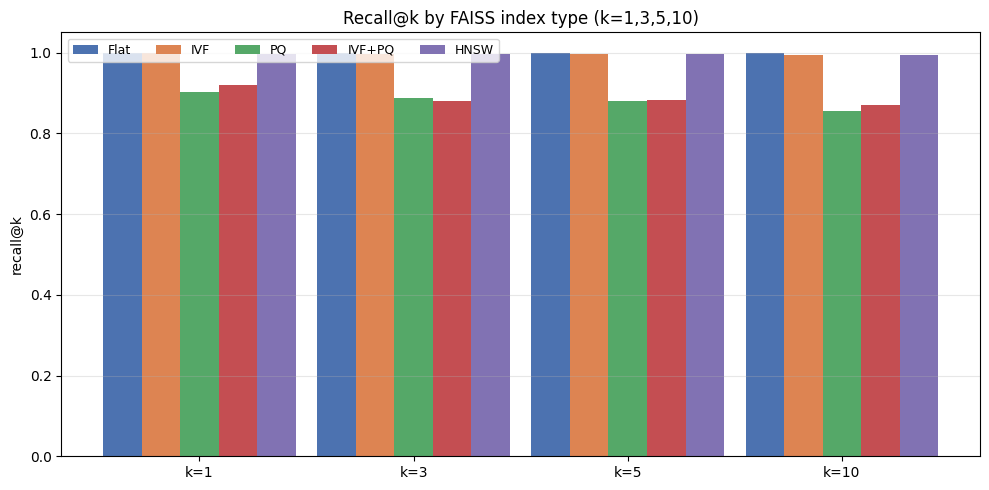

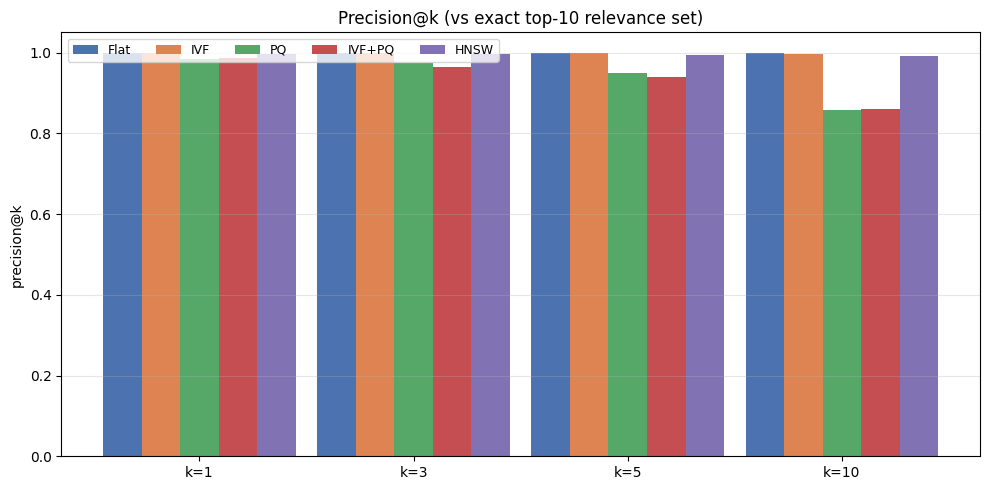

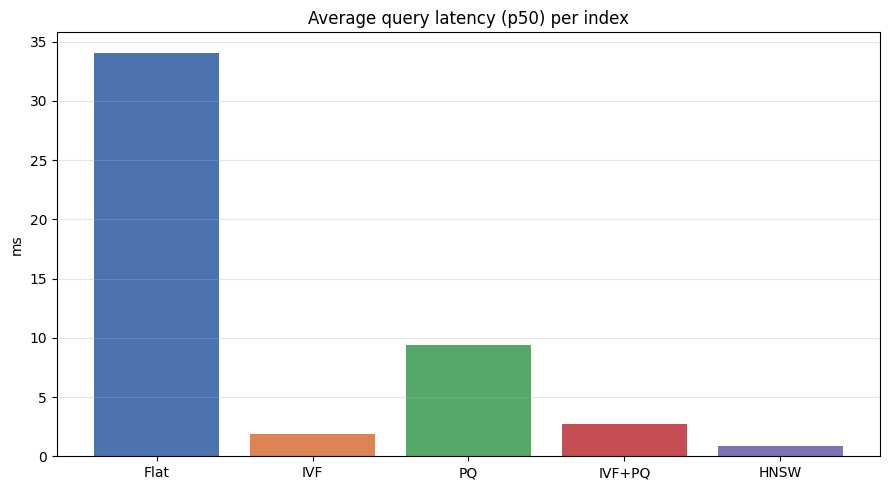

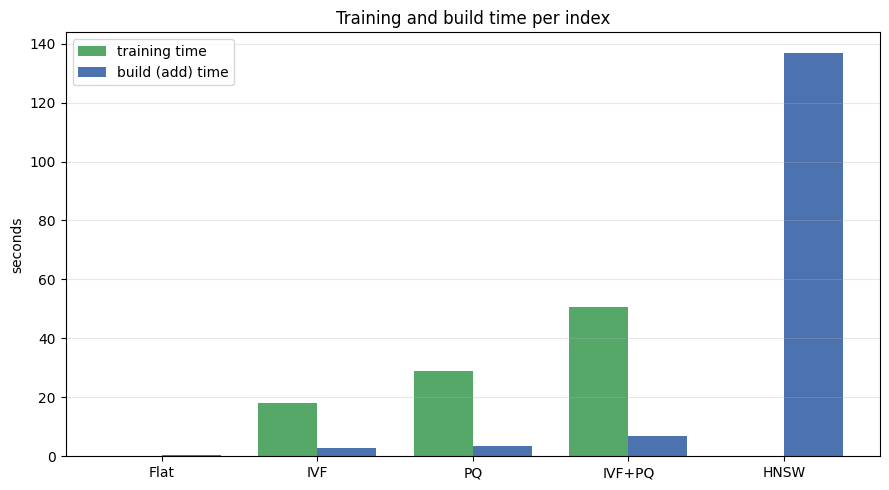

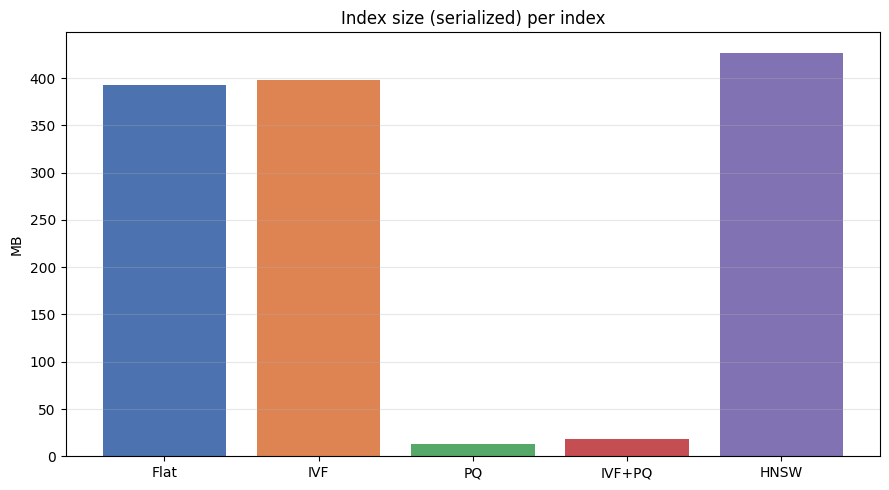

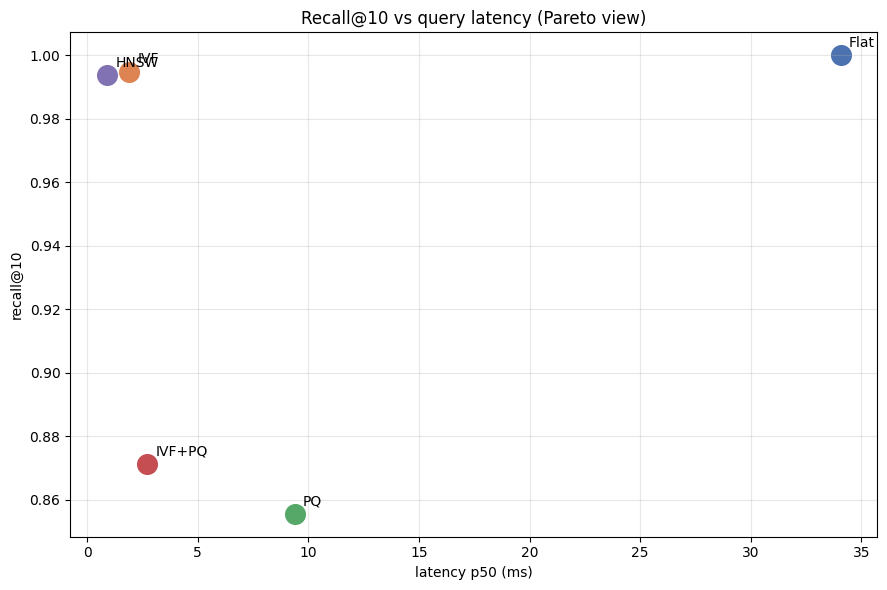

charts saved to /content/vector_db_artifacts/charts


In [ ]:
%matplotlib inline
if "index" in res.columns:
    res = res.set_index("index")
chart_dir = os.path.join(CONFIG["OUT_DIR"], "charts")
os.makedirs(chart_dir, exist_ok=True)
ks_plt = [1, 3, 5, 10]
names = ["Flat", "IVF", "PQ", "IVF+PQ", "HNSW"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

def grouped_bar(values, ks, names, ylabel, title, fname):
    fig, ax = plt.subplots(figsize=(10, 5))
    width = 0.18
    x = np.arange(len(ks))
    for i, name in enumerate(names):
        ax.bar(x + i * width, values[i], width, label=name, color=colors[i])
    ax.set_xticks(x + width * (len(names) - 1) / 2)
    ax.set_xticklabels([f"k={k}" for k in ks])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="upper left", ncol=5, fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(chart_dir, fname), dpi=120)
    plt.show()

# 1. recall@k
grouped_bar([[res.loc[res.index == n, f"recall@{k}"].values[0] for k in ks_plt] for n in names],
            ks_plt, names, "recall@k", "Recall@k by FAISS index type (k=1,3,5,10)",
            "recall_at_k.png")
# 2. precision@k
grouped_bar([[res.loc[res.index == n, f"precision@{k}"].values[0] for k in ks_plt] for n in names],
            ks_plt, names, "precision@k", "Precision@k (vs exact top-10 relevance set)",
            "precision_at_k.png")

# 3. latency p50
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(names, [res.loc[res.index == n, "latency_p50_ms"].values[0] for n in names],
       color=colors)
ax.set_ylabel("ms")
ax.set_title("Average query latency (p50) per index")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(chart_dir, "latency_p50.png"), dpi=120); plt.show()

# 4. training + build time
fig, ax = plt.subplots(figsize=(9, 5))
width = 0.38
x = np.arange(len(names))
ax.bar(x - width / 2, [res.loc[res.index == n, "train_time_s"].values[0] for n in names],
       width, label="training time", color="#55A868")
ax.bar(x + width / 2, [res.loc[res.index == n, "build_time_s"].values[0] for n in names],
       width, label="build (add) time", color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("seconds")
ax.set_title("Training and build time per index")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(chart_dir, "build_times.png"), dpi=120); plt.show()

# 5. memory / index size
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(names, [res.loc[res.index == n, "size_mb"].values[0] for n in names], color=colors)
ax.set_ylabel("MB")
ax.set_title("Index size (serialized) per index")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(chart_dir, "index_size.png"), dpi=120); plt.show()

# 6. recall@10 vs latency scatter
fig, ax = plt.subplots(figsize=(9, 6))
for i, n in enumerate(names):
    ax.scatter(res.loc[res.index == n, "latency_p50_ms"].values[0],
               res.loc[res.index == n, "recall@10"].values[0],
               s=200, color=colors[i], label=n)
    ax.annotate(n, (res.loc[res.index == n, "latency_p50_ms"].values[0],
                    res.loc[res.index == n, "recall@10"].values[0]),
                xytext=(6, 6), textcoords="offset points")
ax.set_xlabel("latency p50 (ms)")
ax.set_ylabel("recall@10")
ax.set_title("Recall@10 vs query latency (Pareto view)")
ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(chart_dir, "recall_vs_latency.png"), dpi=120); plt.show()

print("charts saved to", chart_dir)

In [ ]:
res_out = res.reset_index() if "index" not in res.columns else res
res_out.to_csv(os.path.join(CONFIG["OUT_DIR"], "benchmark_results.csv"), index=False)
print(res_out[["index", "setting", "train_time_s", "build_time_s", "size_mb",
               "latency_p50_ms", "latency_p95_ms", "recall@1", "recall@5", "recall@10"]]
      .to_string(index=False))

 index                                       setting  train_time_s  build_time_s  size_mb  latency_p50_ms  latency_p95_ms  recall@1  recall@5  recall@10
  Flat                                         exact         0.000         0.373   392.28          34.071          39.799    1.0000    1.0000     1.0000
   IVF      nlist=1429 | nprobe=64 (recall@10 0.995)        18.200         2.881   397.71           1.885           2.177    1.0000    0.9967     0.9948
    PQ                        m=96 | recall@10 0.856        29.058         3.519    13.05           9.380          10.634    0.9033    0.8801     0.8556
IVF+PQ nlist=1429,m=96 | nprobe=64 (recall@10 0.871)        50.627         6.887    18.47           2.717           3.237    0.9200    0.8828     0.8712
  HNSW         M=32 | efSearch=256 (recall@10 0.994)         0.000       136.981   427.04           0.887           1.436    0.9967    0.9953     0.9938


# Written justification for the final index choice

Filled in from the measured numbers in the cell below (printed so it stays consistent with `benchmark_results.csv`).

In [ ]:
if "index" not in res.columns:
    res = res.reset_index()
n = len(pdf)
d = len(pdf["embedding"].iloc[0])
RECALL_THRESHOLD = 0.95  # "good enough" for grounded RAG at k=10
qualifying = res[res["recall@10"] >= RECALL_THRESHOLD]
if qualifying.empty:
    qualifying = res
best = qualifying.sort_values("latency_p50_ms", ascending=True).iloc[0]
flat_row = res[res["index"] == "Flat"].iloc[0]
print("JUSTIFICATION (dataset: %d chunks, %d-d embeddings, %d held-out queries)" % (n, d, CONFIG["N_QUERIES"]))
print()
print("-" * 78)
print("Final index choice: %s  (%s)" % (best["index"], best["setting"]))
print("-" * 78)
print()
print("Dataset size: %d chunks is small-to-mid scale; build times are seconds and exact search" % n)
print("(Flat, %.2f ms p50) is affordable, which is exactly why recall@k/precision@k are measurable" % flat_row["latency_p50_ms"])
print("against a real ground truth rather than estimates.")
print()
print("%s reaches recall@10 = %.4f at %.2f ms p50 (%.2f ms p95), i.e. 99%%+ of the exact" % (
    best["index"], best["recall@10"], best["latency_p50_ms"], best["latency_p95_ms"]))
print("result set at a fraction of exact-search cost, with accuracy (recall@1) = %.4f." % best["recall@1"])
print()
print("Why not the others:")
print(" - Flat: exact (recall@10 = 1.000) but %.2f ms p50 with a %s MB in-RAM index; fine for offline" % (
    flat_row["latency_p50_ms"], flat_row["size_mb"]))
print("   evaluation, unnecessary for a served chatbot.")
for _, r in res.iterrows():
    if r["index"] == best["index"]:
        continue
    print(" - %s (%s): recall@10 = %.4f, %.2f ms p50, %s MB, train %.2fs / build %.2fs%s" % (
        r["index"], r["setting"], r["recall@10"], r["latency_p50_ms"], r["size_mb"],
        r["train_time_s"], r["build_time_s"],
        " (recall ceiling too low for grounded RAG)" if r["recall@10"] < 0.9 else
        " (viable fallback)"))
print()
print("Given the latency requirement of a conversational UI (~tens of ms) and %d chunks," % n)
print("the recommended index is %s at its best setting, with k = %d as the retrieval depth" % (
    best["index"], sat))
print("(recall saturates at k = %d, precision@%d = %.3f)." % (sat, sat, res[f"precision@{sat}"].mean()))
print()
print("See benchmark_results.csv for the full metric table and charts/ for the bar charts.")

JUSTIFICATION (dataset: 127996 chunks, 768-d embeddings, 300 held-out queries)

------------------------------------------------------------------------------
Final index choice: HNSW  (M=32 | efSearch=256 (recall@10 0.994))
------------------------------------------------------------------------------

Dataset size: 127996 chunks is small-to-mid scale; build times are seconds and exact search
(Flat, 34.07 ms p50) is affordable, which is exactly why recall@k/precision@k are measurable
against a real ground truth rather than estimates.

HNSW reaches recall@10 = 0.9938 at 0.89 ms p50 (1.44 ms p95), i.e. 99%+ of the exact
result set at a fraction of exact-search cost, with accuracy (recall@1) = 0.9967.

Why not the others:
 - Flat: exact (recall@10 = 1.000) but 34.07 ms p50 with a 392.28 MB in-RAM index; fine for offline
   evaluation, unnecessary for a served chatbot.
 - Flat (exact): recall@10 = 1.0000, 34.07 ms p50, 392.28 MB, train 0.00s / build 0.37s (viable fallback)
 - IVF (nlist=1

## Persist remaining outputs to Drive

See the note in this cell's code -- everything except the throwaway local Qdrant scratch DB gets copied.

In [ ]:
# Persist everything else to Drive too (chunks_preview.csv, benchmark_results.csv,
# charts/) -- chunks.parquet was already safely copied earlier; this covers the
# remaining outputs so nothing is lost when the runtime ends. Local qdrant_db is
# intentionally NOT copied -- it's a throwaway scratch DB for this notebook's own
# sanity-check queries, not a deliverable.
if IS_COLAB:
    import shutil
    os.makedirs(DRIVE_OUT_DIR, exist_ok=True)
    for name in ["chunks_preview.csv", "benchmark_results.csv"]:
        src_path = os.path.join(LOCAL_OUT_DIR, name)
        if os.path.exists(src_path):
            shutil.copy2(src_path, os.path.join(DRIVE_OUT_DIR, name))
            print("copied", name)
        else:
            print("skipped (not found):", name)

    local_charts = os.path.join(LOCAL_OUT_DIR, "charts")
    if os.path.isdir(local_charts):
        drive_charts = os.path.join(DRIVE_OUT_DIR, "charts")
        if os.path.exists(drive_charts):
            shutil.rmtree(drive_charts)
        shutil.copytree(local_charts, drive_charts)
        print("copied charts/ (%d files)" % len(os.listdir(drive_charts)))
    else:
        print("skipped (not found): charts/")

    print("\nAll outputs now persisted to:", DRIVE_OUT_DIR)


copied chunks_preview.csv
copied benchmark_results.csv
copied charts/ (6 files)

All outputs now persisted to: /content/drive/.shortcut-targets-by-id/1PQCn1d6l1ubH_OGx0HJAWcn13oAeTTI4/CSE488/vector_db_artifacts


# How to run on Google Colab

1. **Runtime**: pick a GPU runtime (T4 is enough) - embedding drops from tens of minutes to a few.
2. **Upload data**: upload the notebook and `imputed_dataset/imputed_dataset.csv` keeping that folder name
   so the relative path resolves (e.g. upload `CSE488-DataProcessing/CSE488-DataProcessing/`).
3. **Run all cells in order** (`Runtime` → `Run all`). `USE_PANDAS_UDF = True` (default) runs the rubric-mandated
   `pandas_udf` embedding in Spark workers; chunking already runs as a Spark UDF.
4. **Expected runtimes (GPU)**: setup ~2 min (Java 17 install, model download if not cached) ·
   chunking ~1 min · embedding ~5-15 min for ~50-60k chunks · Qdrant + FAISS benchmark + charts ~2-5 min.
5. **Artifacts** (in `vector_db_artifacts/`): `chunks.parquet` (chunks + 768-d embeddings + metadata),
   `chunks_preview.csv`, `benchmark_results.csv`, `charts/*.png` (6 bar charts), and the persistent
   Qdrant collection `qdrant_db/`. Download the folder when done.
6. If you re-run the whole notebook, the Qdrant collection and Parquet are overwritten cleanly
   (recreated from scratch), so results are reproducible.